In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import functionsTP as myfunc
import time

In [2]:
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, noise)
    return noisy_image

## Bilateral filter Implementation 

Height: 400, Width: 600, Channels: 1


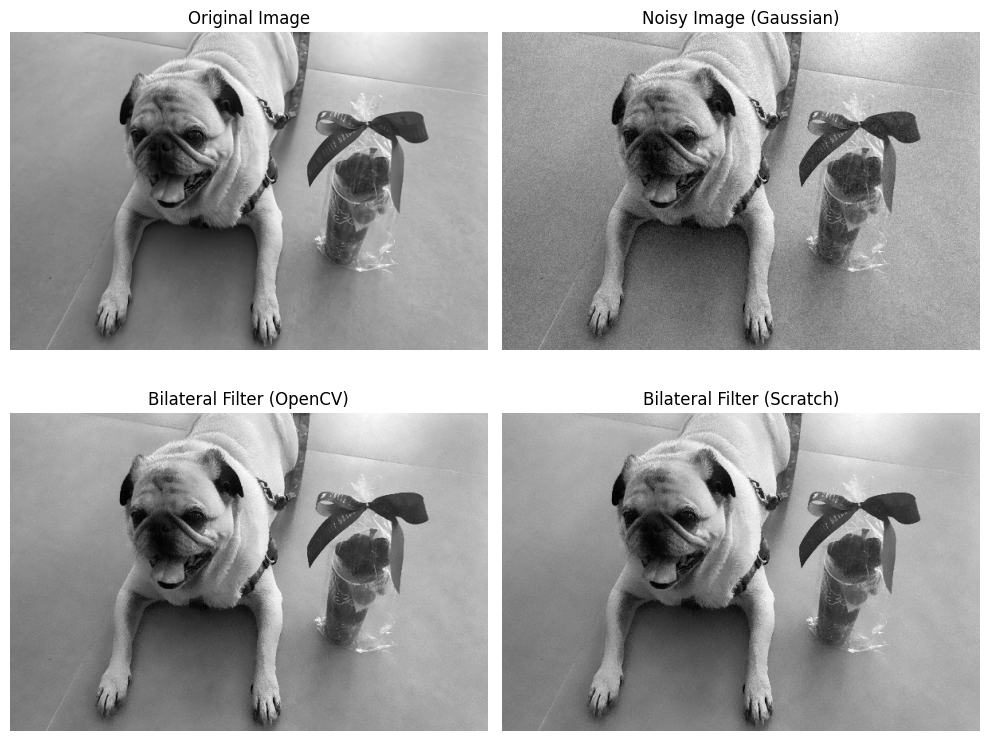

In [3]:
image_path = 'images/Image1.jpg'
L_image = cv2.imread(image_path)
L_image = cv2.resize(L_image, (600, 400))
image = cv2.cvtColor(L_image, cv2.COLOR_BGR2GRAY)

print(f"Height: {image.shape[0]}, Width: {image.shape[1]}, Channels: 1")

mean = 0
sigma = 10 
gaussian_noise = np.random.normal(mean, sigma, image.shape)

noisy_image = image.astype(np.float32) + gaussian_noise
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

filtered_image_OpenCV = cv2.bilateralFilter(noisy_image, 15, 15.0, 15.0)
filtered_image_Scratch = myfunc.bilateral_filter_scratch(noisy_image, 15, 15.0, 15.0)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Original image
axs[0, 0].imshow(image, cmap='gray')
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

# Noisy image
axs[0, 1].imshow(noisy_image, cmap='gray')
axs[0, 1].set_title('Noisy Image (Gaussian)')
axs[0, 1].axis('off')

# OpenCV Bilateral Filter
axs[1, 0].imshow(filtered_image_OpenCV, cmap='gray')
axs[1, 0].set_title('Bilateral Filter (OpenCV)')
axs[1, 0].axis('off')

# Scratch Bilateral Filter
axs[1, 1].imshow(filtered_image_Scratch, cmap='gray')
axs[1, 1].set_title('Bilateral Filter (Scratch)')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()


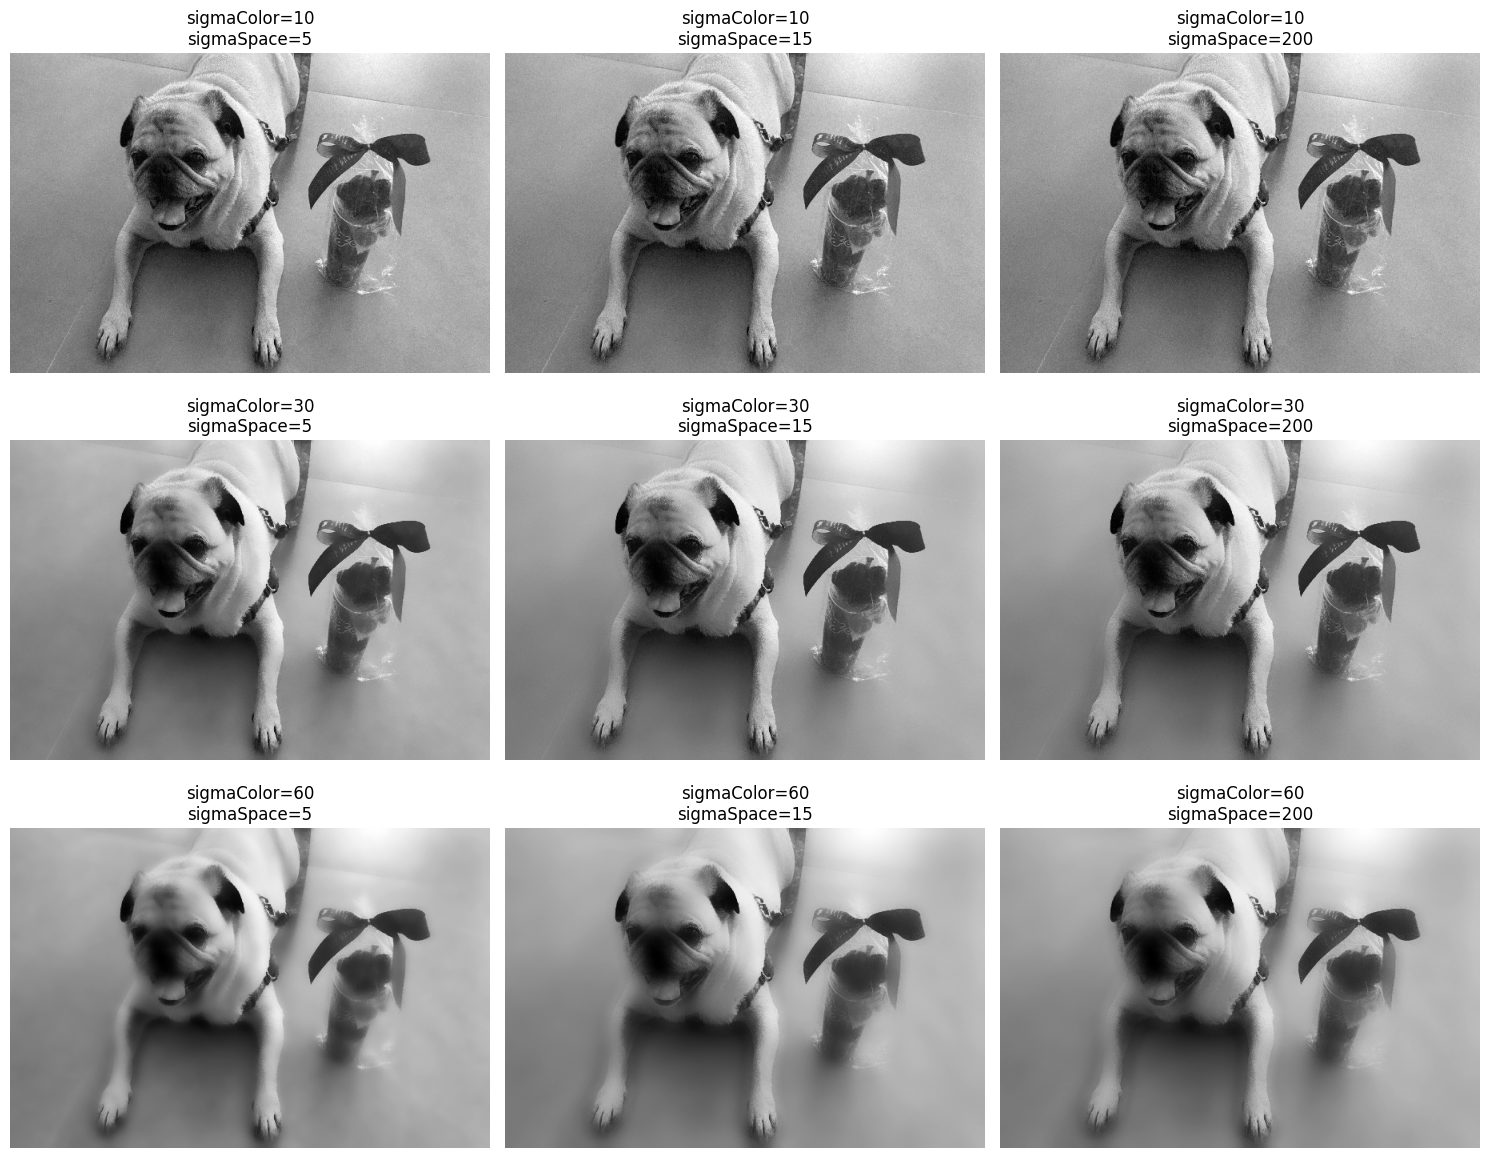

In [4]:
sigma_spaces = [5, 15, 200]
sigma_colors = [10, 30, 60]

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

for i, sigma_color in enumerate(sigma_colors):
    for j, sigma_space in enumerate(sigma_spaces):
        filtered = cv2.bilateralFilter(noisy_image, d=30, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'sigmaColor={sigma_color}\nsigmaSpace={sigma_space}')
        ax.axis('off')

plt.tight_layout()
plt.show()

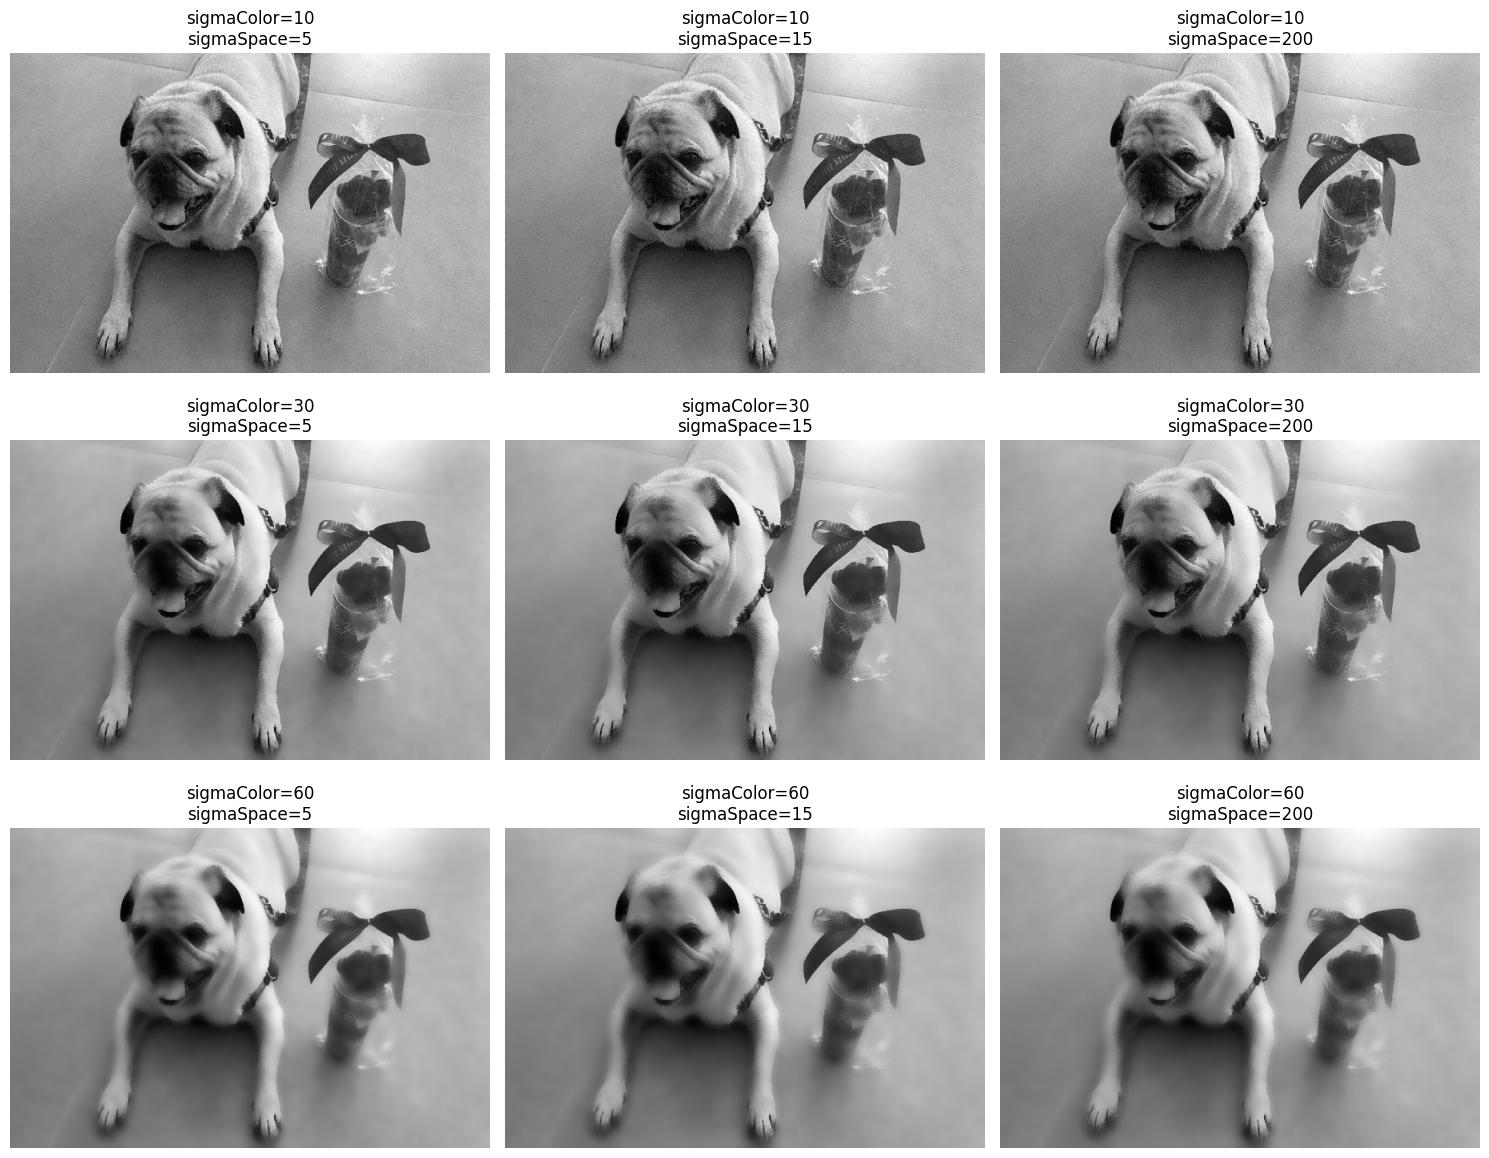

In [45]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12))

for i, sigma_color in enumerate(sigma_colors):
    for j, sigma_space in enumerate(sigma_spaces):
        filtered = myfunc.bilateral_filter_scratch(noisy_image, 15, sigma_color, sigma_space)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'sigmaColor={sigma_color}\nsigmaSpace={sigma_space}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def compare_filters(noisy_image, image, d_values, sigma_values):
    results = {
        'bilateral': {'mse': float('inf')},
        'bilateral_cv2': {'mse': float('inf')},
        'gaussian': {'mse': float('inf')}
    }

    for d in d_values:
        for sigma in sigma_values:
            # Bilateral filter scratch
            filtered_bilat = myfunc.bilateral_filter_scratch(noisy_image, d, sigma, sigma)
            mse_bilat = mean_squared_error(image, filtered_bilat)
            
            if mse_bilat < results['bilateral']['mse']:
                psnr_bilat = peak_signal_noise_ratio(image, filtered_bilat, data_range=255)
                ssim_bilat = structural_similarity(image, filtered_bilat, data_range=255)
                results['bilateral'] = {
                    'd': d,
                    'sigma': sigma,
                    'mse': mse_bilat,
                    'psnr': psnr_bilat,
                    'ssim': ssim_bilat
                }
            
            # Bilateral filter
            filtered_bilat_cv2 = cv2.bilateralFilter(noisy_image, d, sigma, sigma)
            mse_bilat_cv2 = mean_squared_error(image, filtered_bilat_cv2)
            
            if mse_bilat_cv2 < results['bilateral_cv2']['mse']:
                psnr_bilat_cv2 = peak_signal_noise_ratio(image, filtered_bilat_cv2, data_range=255)
                ssim_bilat_cv2 = structural_similarity(image, filtered_bilat_cv2, data_range=255)
                results['bilateral_cv2'] = {
                    'd': d,
                    'sigma': sigma,
                    'mse': mse_bilat_cv2,
                    'psnr': psnr_bilat_cv2,
                    'ssim': ssim_bilat_cv2
                }
            
            # Gaussian filter 
            if d % 2 == 1:
                filtered_gauss = cv2.GaussianBlur(noisy_image, (d, d), sigmaX=sigma)
                mse_gauss = mean_squared_error(image, filtered_gauss)
                
                if mse_gauss < results['gaussian']['mse']:
                    psnr_gauss = peak_signal_noise_ratio(image, filtered_gauss, data_range=255)
                    ssim_gauss = structural_similarity(image, filtered_gauss, data_range=255)
                    results['gaussian'] = {
                        'd': d,
                        'sigma': sigma,
                        'mse': mse_gauss,
                        'psnr': psnr_gauss,
                        'ssim': ssim_gauss
                    }

    return results

In [48]:
d_values = [3, 5, 9, 15]  
sigma_values = [3, 5, 10, 15, 20, 25]

results = compare_filters(noisy_image, image, d_values, sigma_values)

print("Bilateral Filter (scratch):")
r = results['bilateral']
print(f"d={r['d']}, sigma={r['sigma']} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")

print("\nBilateral Filter (cv2):")
r = results['bilateral_cv2']
print(f"d={r['d']}, sigma={r['sigma']} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")

print("\nGaussian Filter:")
r = results['gaussian']
print(f"d={r['d']}, sigma={r['sigma']} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")

Bilateral Filter (scratch):
d=9, sigma=25 | MSE=369.86 | PSNR=22.45 | SSIM=0.3105

Bilateral Filter (cv2):
d=15, sigma=25 | MSE=368.27 | PSNR=22.47 | SSIM=0.3077

Gaussian Filter:
d=5, sigma=3 | MSE=108.16 | PSNR=27.79 | SSIM=0.6736


## Isotropic diffusion

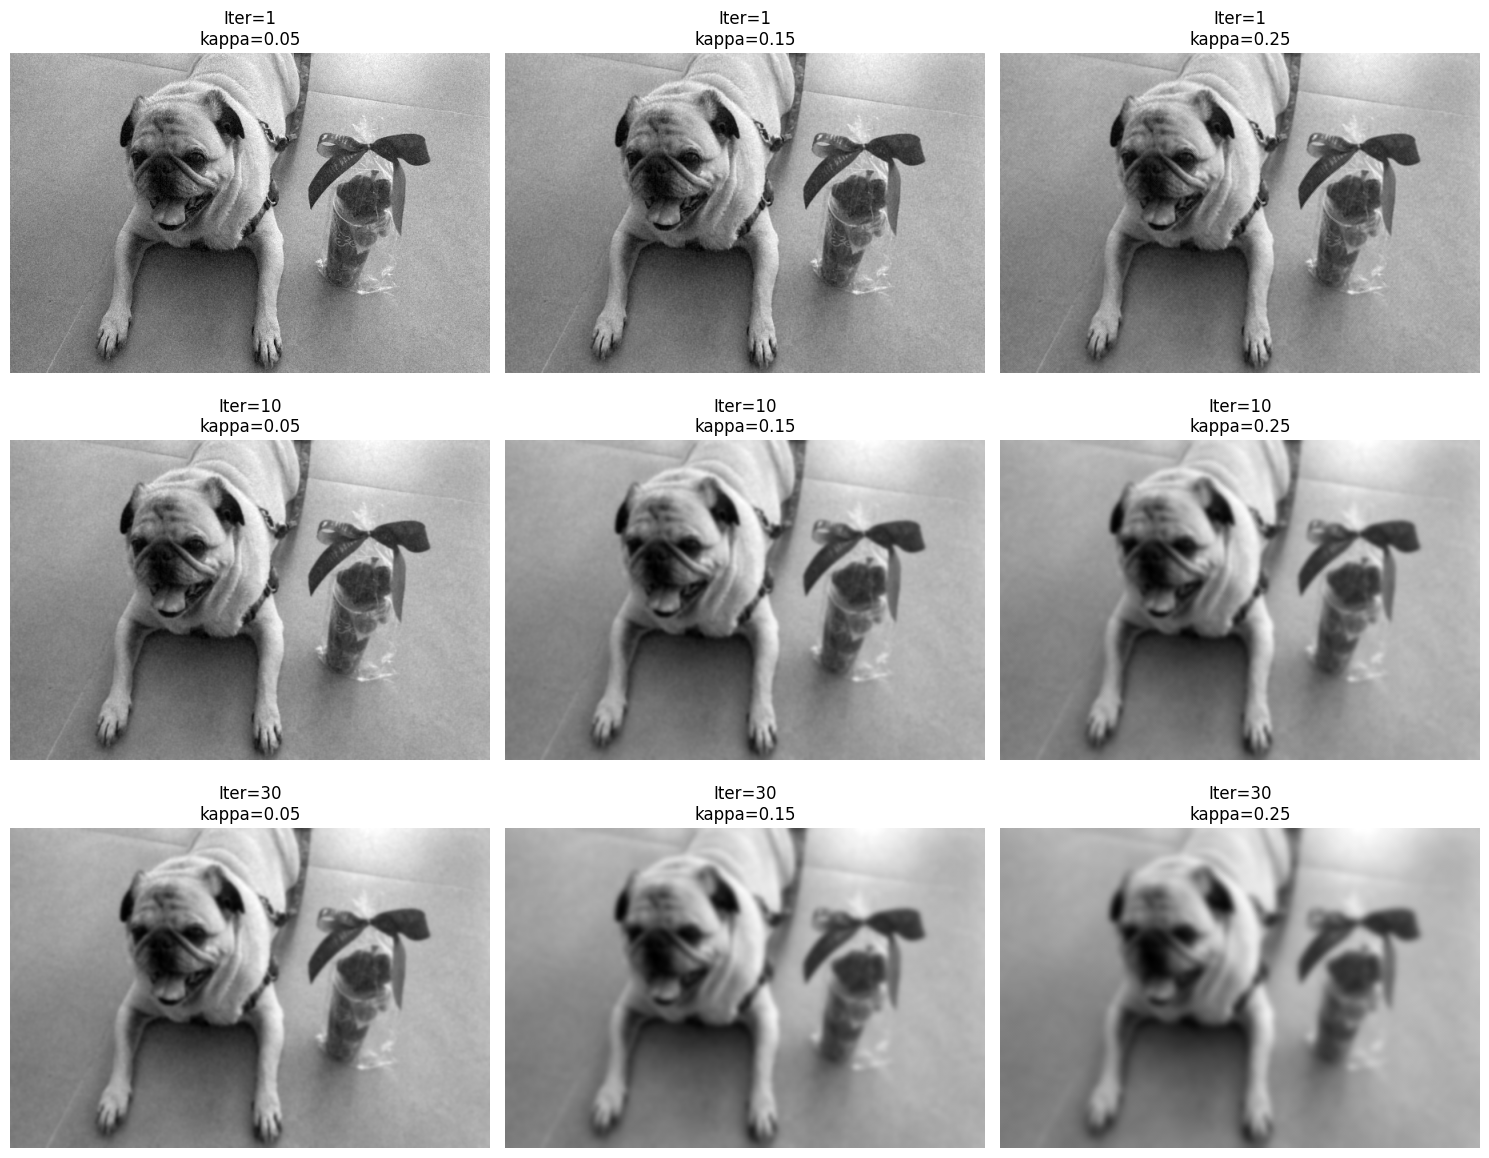

In [15]:
n_iters = [1, 10, 30]
kappas = [0.05, 0.15, 0.25]

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

for i, n_iter in enumerate(n_iters):
    for j, kappa in enumerate(kappas):
        filtered = myfunc.isotropic_diffusion(noisy_image, n_iter, kappa)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'Iter={n_iter}\nkappa={kappa}')
        ax.axis('off')

plt.tight_layout()
plt.show()

## Anisotropic diffusion

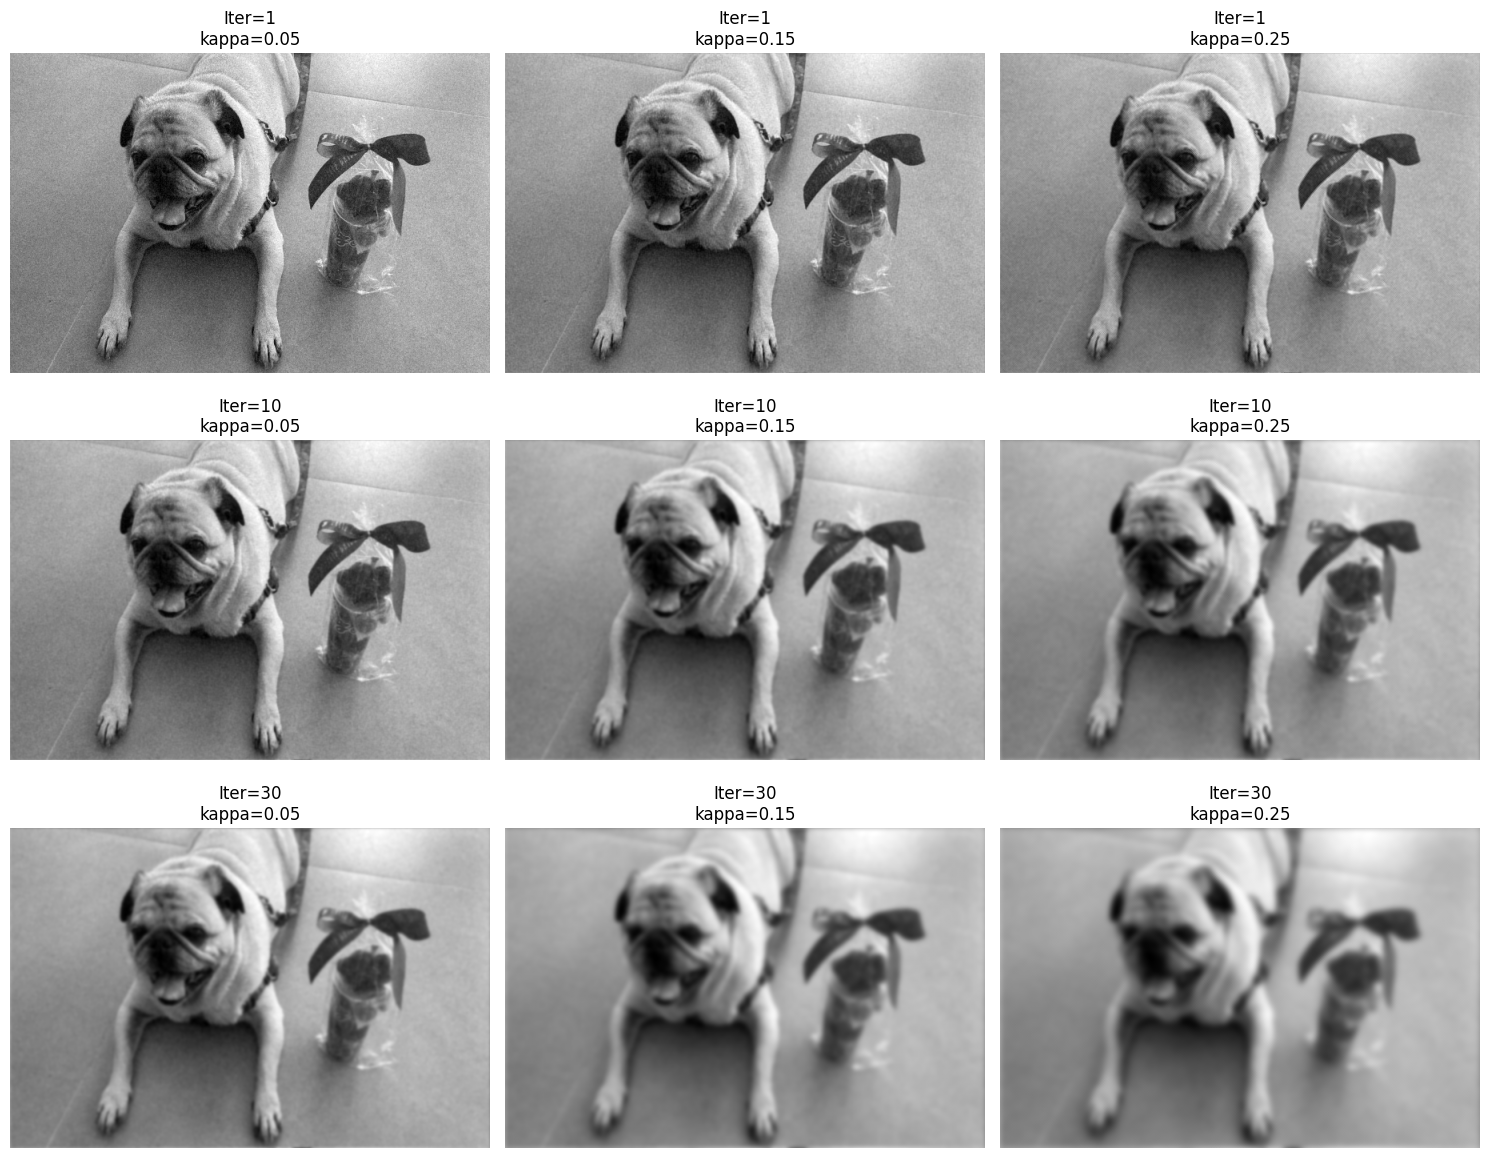

In [16]:
n_iters = [1, 10, 30]
kappas = [0.05, 0.15, 0.25]

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

for i, n_iter in enumerate(n_iters):
    for j, kappa in enumerate(kappas):
        filtered = myfunc.anisotropic_diffusion(noisy_image, n_iter, kappa)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'Iter={n_iter}\nkappa={kappa}')
        ax.axis('off')

plt.tight_layout()
plt.show()

## Compare diffusion

In [ ]:
def compare_diffusion_filters_optimized(noisy_image, image, n_iter_values, kappas):
    results = {
        'isotropic': {'mse': float('inf')},
        'anisotropic': {'mse': float('inf')}
    }
    
    noisy_image = noisy_image.astype(np.float32)
    noisy_image = noisy_image / noisy_image.max()  
    
    image = image.astype(np.float32)
    image = image / image.max()  
    
    for n_iter in n_iter_values:
        for kappa in kappas:
            # Isotropic diffusion
            filtered_isotropic = myfunc.isotropic_diffusion(noisy_image, n_iter, kappa)
            mse_isotropic = mean_squared_error(image, filtered_isotropic)
            
            if mse_isotropic < results['isotropic']['mse']:
                psnr_isotropic = peak_signal_noise_ratio(image, filtered_isotropic, data_range=1)
                ssim_isotropic = structural_similarity(image, filtered_isotropic, data_range=1)
                results['isotropic'] = {
                    'n_iter': n_iter,
                    'kappa': kappa,
                    'mse': mse_isotropic,
                    'psnr': psnr_isotropic,
                    'ssim': ssim_isotropic
                }
            
            # Anisotropic diffusion
            filtered_anisotropic = myfunc.anisotropic_diffusion(noisy_image, n_iter, kappa)
            mse_anisotropic = mean_squared_error(image, filtered_anisotropic)
            
            if mse_anisotropic < results['anisotropic']['mse']:
                psnr_anisotropic = peak_signal_noise_ratio(image, filtered_anisotropic, data_range=1)
                ssim_anisotropic = structural_similarity(image, filtered_anisotropic, data_range=1)
                results['anisotropic'] = {
                    'n_iter': n_iter,
                    'kappa': kappa,
                    'mse': mse_anisotropic,
                    'psnr': psnr_anisotropic,
                    'ssim': ssim_anisotropic
                }
    
    return results

In [19]:
n_iter_values = [0, 1, 3, 5, 10]
kappas = [0.05, 0.15, 0.25]

diffusion_results = compare_diffusion_filters_optimized(noisy_image, image, n_iter_values, kappas)

print("Isotropic Diffusion:")
r = diffusion_results['isotropic']
print(f"n_iter={r['n_iter']} kappa={r['kappa']} | MSE={r['mse']:.4f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")

print("\nAnisotropic Diffusion:")
r = diffusion_results['anisotropic']
print(f"n_iter={r['n_iter']} kappa={r['kappa']} | MSE={r['mse']:.4f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")

Isotropic Diffusion:
n_iter=5 kappa=0.05 | MSE=0.0006 | PSNR=31.90 | SSIM=0.8092

Anisotropic Diffusion:
n_iter=5 kappa=0.05 | MSE=0.0007 | PSNR=31.79 | SSIM=0.8084
